Phase 1: Data Loading & Cleaning (The Setup)
Your first task is to get the data ready for the machine learning algorithms.

• Load the Data: Import the dataset using Pandas. (Hint: seaborn has a built-in
load_dataset(’penguins’) function).

• Explore: Use functions like .head(), .info(), and .describe() to understand the
columns.

• Clean: This dataset has missing values (NaNs). You must identify them and drop
the missing rows using Pandas before moving forward.

In [30]:
import pandas as pd
import seaborn as sns
import numpy as np



In [31]:
df=sns.load_dataset('penguins')
print(df.head())
print(df.info())
print(df.describe())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_

In [32]:
print(df.isnull().sum())
df=df.dropna()
print('Missing values after cleaning:')
print(df.isnull().sum())
print(df.shape)


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
Missing values after cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
(333, 7)


Phase 2: The Model Race (Training)

Now that your data is clean, it is time to build and compare two different classification
models.

• Split the Data: Separate your features (measurements) from your labels (species),
and  perform a Train-Test Split.

• Model1:   Initialize, fit, and predict using a k-Nearest Neighbors (k-NN) classifier.

• Model 2: Initialize, fit, and predict using a Decision Tree classifier

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])


X=df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']]
y=df['species']


In [34]:
from sklearn.model_selection import train_test_split as tts

X_train, X_test, y_train, y_test = tts(
    X, y, test_size=0.2, random_state=42
)


In [35]:
from sklearn.neighbors import KNeighborsClassifier as KN
knn=KN(n_neighbors= 5)
knn.fit(X_train, y_train)

knn_predictions=knn.predict(X_test)

In [36]:
from sklearn.tree import DecisionTreeClassifier as DC
dt=DC(random_state=42)
dt.fit(X_train, y_train)

dt_predictions=dt.predict(X_test)


Phase 3: The Proof (Evaluation & Interpretability)

A good researcher always proves their results. In this final step, you will evaluate which
model performed best and explain why.

• Evaluate: Calculate the Accuracy for both models. Generate a Confusion Matrix
for your best-performing model to show exactly where it made correct or incorrect
predictions.

• Interpret: Create a simple Feature Importance visualization (or explain it in text) to
show which physical trait—like flipper length or bill depth—was the most important
factor in classifying the penguins.

In [37]:
from sklearn.metrics import accuracy_score

acc_knn=accuracy_score(y_test,knn_predictions)
acc_dt=accuracy_score(y_test,dt_predictions)

print("Model 1(KNN) accuracy:",acc_knn)
print("Model 2(Decision Tree) accuracy:",acc_dt)

if acc_dt > acc_knn:
    best_predictions = dt_predictions
    print("Decision Tree is selected")
else:
    best_predictions = knn_predictions
    print("KNN is selected")





Model 1(KNN) accuracy: 0.8208955223880597
Model 2(Decision Tree) accuracy: 1.0
Decision Tree is selected


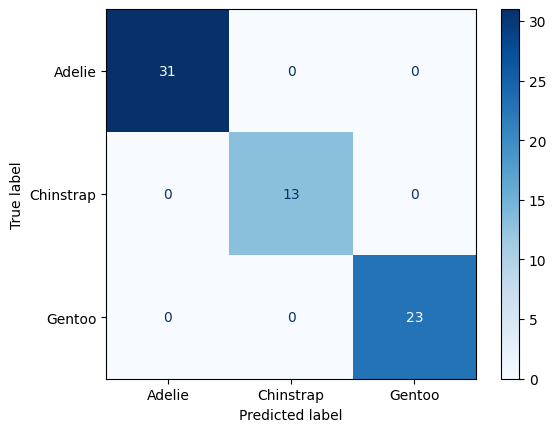

In [38]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,best_predictions)
ConfusionMatrixDisplay(cm,display_labels=le.classes_).plot(cmap='Blues')
plt.show()

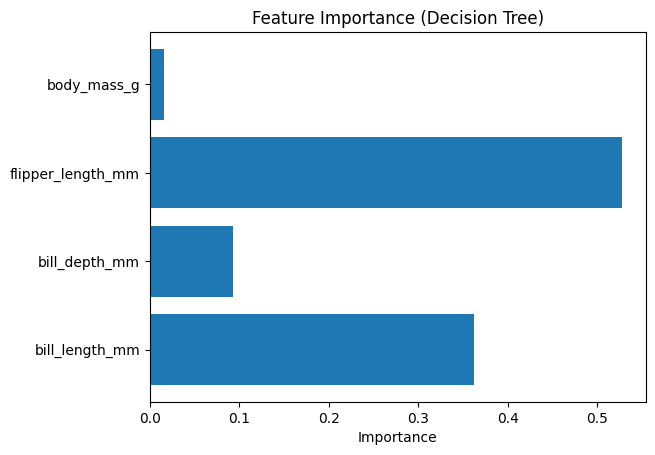

Most important feature: flipper_length_mm


In [39]:
features = X.columns
importances = dt.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Decision Tree)")
plt.show()

print("Most important feature:", features[importances.argmax()])